# 00 - Raw Data EDA: Olist E-Commerce Dataset

**Member 1 | Data Ingestion Stage**

This notebook explores the raw data loaded into BigQuery via Meltano from the [Brazilian E-Commerce Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

**Goals:**
- Verify all 8 tables were loaded correctly
- Understand table shapes, data types, and time ranges
- Identify obvious data quality issues for downstream members
- Provide a foundation for Member 2 (Warehouse Design) and Member 4 (Data Quality Testing)


## 0. Setup & Connection

In [1]:
# Install dependencies if needed
# !pip install google-cloud-bigquery pandas pandas-gbq db-dtypes pyarrow

In [2]:
import os
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────────────────────────
PROJECT_ID = "olist-assignment-497915"   # ← your GCP project
DATASET    = "olist_raw"

# Authentication: set GOOGLE_APPLICATION_CREDENTIALS env var, or use ADC
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/path/to/service_account.json"

client = bigquery.Client(project=PROJECT_ID)
print(f"Connected to BigQuery project: {PROJECT_ID}")

E0000 00:00:1780224761.644896 73412176 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780224761.645459 73412176 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780224761.645462 73412176 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780224761.645465 73412176 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780224761.645467 73412176 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


Connected to BigQuery project: olist-assignment-497915


## 1. Verify All Tables Exist

In [3]:
EXPECTED_TABLES = [
    "orders", "customers", "products", "order_items",
    "order_payments", "order_reviews", "sellers", "category_translation"
]

# List actual tables in dataset
tables_in_bq = [t.table_id for t in client.list_tables(f"{PROJECT_ID}.{DATASET}")]

print(f"{'Table':<25} {'Status'}")
print("-" * 35)
for t in EXPECTED_TABLES:
    status = "✅ Found" if t in tables_in_bq else "❌ MISSING"
    print(f"{t:<25} {status}")

missing = [t for t in EXPECTED_TABLES if t not in tables_in_bq]
if not missing:
    print("\n✅ All 8 tables loaded successfully!")
else:
    print(f"\n⚠️  Missing tables: {missing}")

Table                     Status
-----------------------------------
orders                    ✅ Found
customers                 ✅ Found
products                  ✅ Found
order_items               ✅ Found
order_payments            ✅ Found
order_reviews             ✅ Found
sellers                   ✅ Found
category_translation      ✅ Found

✅ All 8 tables loaded successfully!


## 2. Row Counts & Table Sizes

In [4]:

def get_row_count(table_name):
    query = f"SELECT COUNT(*) as cnt FROM `{PROJECT_ID}.{DATASET}.{table_name}`"
    return client.query(query).result().to_dataframe()["cnt"][0]

row_counts = {t: get_row_count(t) for t in EXPECTED_TABLES}

df_counts = pd.DataFrame(
    [(k, v) for k, v in row_counts.items()],
    columns=["Table", "Row Count"]
).sort_values("Row Count", ascending=False)

print(df_counts.to_string(index=False))
print(f"\nTotal rows across all tables: {df_counts['Row Count'].sum():,}")

               Table  Row Count
         order_items     112650
      order_payments     103886
              orders      99441
           customers      99441
       order_reviews      91500
            products      32951
             sellers       3095
category_translation         71

Total rows across all tables: 543,035


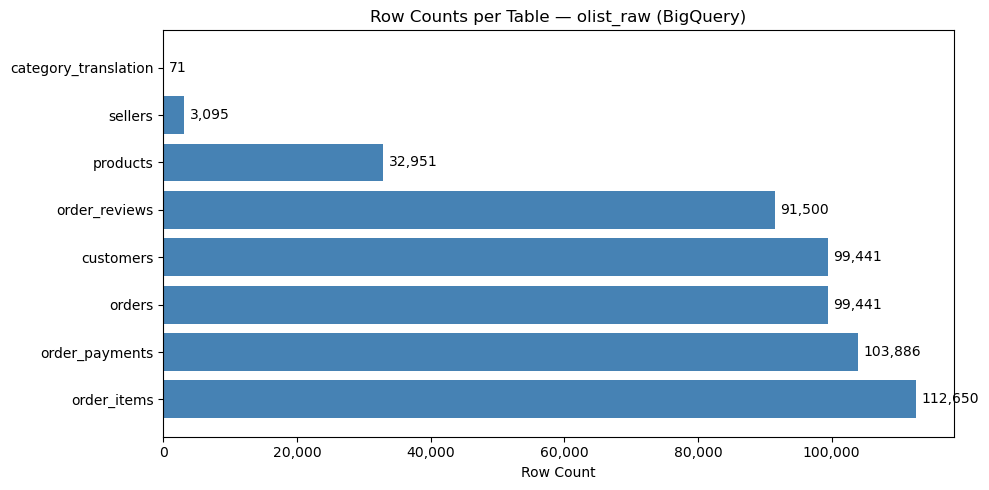

In [5]:
# Bar chart of row counts
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_counts["Table"], df_counts["Row Count"], color="steelblue")
ax.bar_label(bars, fmt="{:,.0f}", padding=4)
ax.set_xlabel("Row Count")
ax.set_title("Row Counts per Table — olist_raw (BigQuery)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("row_counts.png", dpi=150)
plt.show()

## 3. Schema Inspection (Data Types per Table)

In [6]:
def get_schema(table_name):
    table = client.get_table(f"{PROJECT_ID}.{DATASET}.{table_name}")
    return pd.DataFrame(
        [(f.name, f.field_type, f.mode) for f in table.schema],
        columns=["Column", "Type", "Mode"]
    )

for table in EXPECTED_TABLES:
    print(f"\n{'='*50}")
    print(f"  {table}")
    print(f"{'='*50}")
    display(get_schema(table))


  orders


,Column,Type,Mode
0,order_id,STRING,NULLABLE
1,customer_id,STRING,NULLABLE
2,order_status,STRING,NULLABLE
3,order_purchase_timestamp,STRING,NULLABLE
4,order_approved_at,STRING,NULLABLE
5,order_delivered_carrier_date,STRING,NULLABLE
6,order_delivered_customer_date,STRING,NULLABLE
7,order_estimated_delivery_date,STRING,NULLABLE
8,_smart_source_bucket,STRING,NULLABLE
9,_smart_source_file,STRING,NULLABLE



  customers


,Column,Type,Mode
0,customer_id,STRING,NULLABLE
1,customer_unique_id,STRING,NULLABLE
2,customer_zip_code_prefix,INTEGER,NULLABLE
3,customer_city,STRING,NULLABLE
4,customer_state,STRING,NULLABLE
5,_smart_source_bucket,STRING,NULLABLE
6,_smart_source_file,STRING,NULLABLE
7,_smart_source_lineno,INTEGER,NULLABLE
8,_sdc_deleted_at,TIMESTAMP,NULLABLE
9,_sdc_batched_at,TIMESTAMP,NULLABLE



  products


...

,Column,Type,Mode
0,review_id,STRING,NULLABLE
1,order_id,STRING,NULLABLE
2,review_score,INTEGER,NULLABLE
3,review_comment_title,STRING,NULLABLE
4,review_comment_message,STRING,NULLABLE
5,review_creation_date,STRING,NULLABLE
6,review_answer_timestamp,STRING,NULLABLE
7,_smart_source_bucket,STRING,NULLABLE
8,_smart_source_file,STRING,NULLABLE
9,_smart_source_lineno,INTEGER,NULLABLE



  sellers


,Column,Type,Mode
0,seller_id,STRING,NULLABLE
1,seller_zip_code_prefix,INTEGER,NULLABLE
2,seller_city,STRING,NULLABLE
3,seller_state,STRING,NULLABLE
4,_smart_source_bucket,STRING,NULLABLE
5,_smart_source_file,STRING,NULLABLE
6,_smart_source_lineno,INTEGER,NULLABLE
7,_sdc_deleted_at,TIMESTAMP,NULLABLE
8,_sdc_batched_at,TIMESTAMP,NULLABLE
9,_sdc_extracted_at,TIMESTAMP,NULLABLE



  category_translation


,Column,Type,Mode
0,product_category_name,STRING,NULLABLE
1,product_category_name_english,STRING,NULLABLE
2,_smart_source_bucket,STRING,NULLABLE
3,_smart_source_file,STRING,NULLABLE
4,_smart_source_lineno,INTEGER,NULLABLE
5,_sdc_deleted_at,TIMESTAMP,NULLABLE
6,_sdc_batched_at,TIMESTAMP,NULLABLE
7,_sdc_extracted_at,TIMESTAMP,NULLABLE
8,_sdc_received_at,TIMESTAMP,NULLABLE
9,_sdc_sequence,INTEGER,NULLABLE


## 4. Sample Data Preview (Top 5 rows per table)

In [7]:
def preview(table_name, n=5):
    query = f"SELECT * FROM `{PROJECT_ID}.{DATASET}.{table_name}` LIMIT {n}"
    return client.query(query).result().to_dataframe()

for table in EXPECTED_TABLES:
    print(f"\n── {table} ──")
    display(preview(table))


── orders ──


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,_smart_source_bucket,_smart_source_file,_smart_source_lineno,_sdc_deleted_at,_sdc_batched_at,_sdc_extracted_at,_sdc_received_at,_sdc_sequence,_sdc_table_version
0,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,None,None,None,2018-10-01 00:00:00,file:///Users/jinping/Documents/data-learning/...,olist_orders_dataset.csv,99285,NaT,2026-05-31 18:08:25.708368+00:00,NaT,2026-05-31 18:08:25.710657+00:00,1780222105711,<NA>
1,cb6e8557d9afadd1aa602474dafddad8,21acca2de271c02fc746e1573535ed3a,delivered,2018-01-18 11:52:59,2018-01-18 11:59:24,2018-01-18 22:06:16,2018-02-01 12:35:07,2018-02-21 00:00:00,file:///Users/jinping/Documents/data-learning/...,olist_orders_dataset.csv,99036,NaT,2026-05-31 18:08:25.708368+00:00,NaT,2026-05-31 18:08:25.708644+00:00,1780222105709,<NA>
2,7ec1e3874c69a513e785a5b0cc71dafc,a394adc4a10c887539f7cf0ff32e5e93,delivered,2018-05-23 22:23:28,2018-05-23 22:56:49,2018-05-25 10:14:00,2018-06-05 19:39:41,2018-06-14 00:00:00,file:///Users/jinping/Documents/data-learning/...,olist_orders_dataset.csv,99116,NaT,2026-05-31 18:08:25.708368+00:00,NaT,2026-05-31 18:08:25.709427+00:00,1780222105709,<NA>
3,580e9410cdbeb1ec66a48d3d0454dd17,e64813a1e1c56c5f628d71d62b69fe7c,delivered,2017-11-24 02:08:40,2017-11-24 02:29:27,2017-11-28 15:48:46,2017-12-21 20:05:34,2018-01-05 00:00:00,file:///Users/jinping/Documents/data-learning/...,olist_orders_dataset.csv,99031,NaT,2026-05-31 18:08:25.708368+00:00,NaT,2026-05-31 18:08:25.708616+00:00,1780222105709,<NA>
4,5ce8ed74908cd24bd6b5138292ec7b04,565d4f4e889300656969d36628d8ddff,delivered,2018-07-20 21:57:09,2018-07-20 22:10:13,2018-07-23 10:09:00,2018-07-24 16:51:54,2018-07-31 00:00:00,file:///Users/jinping/Documents/data-learning/...,olist_orders_dataset.csv,99114,NaT,2026-05-31 18:08:25.708368+00:00,NaT,2026-05-31 18:08:25.709413+00:00,1780222105709,<NA>



── customers ──


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,_smart_source_bucket,_smart_source_file,_smart_source_lineno,_sdc_deleted_at,_sdc_batched_at,_sdc_extracted_at,_sdc_received_at,_sdc_sequence,_sdc_table_version
0,1612f32963e9825da1018976d1c9e8fc,0e2cdea5b5c9dc617ad5a66dea978812,40375,salvador,BA,file:///Users/jinping/Documents/data-learning/...,olist_customers_dataset.csv,99073,NaT,2026-05-31 18:08:33.664476+00:00,NaT,2026-05-31 18:08:33.664974+00:00,1780222113665,<NA>
1,c46720f5a60dadde920c6d90014317b3,89a830372aaa7e88e564bd757e53a516,44610,pintadas,BA,file:///Users/jinping/Documents/data-learning/...,olist_customers_dataset.csv,99046,NaT,2026-05-31 18:08:33.664476+00:00,NaT,2026-05-31 18:08:33.664804+00:00,1780222113665,<NA>
2,18e56af97c2f24afcfaf7aa97ad2b969,d9ff7e37d7bf448abb783a6e56462d93,63765,sucesso,CE,file:///Users/jinping/Documents/data-learning/...,olist_customers_dataset.csv,99074,NaT,2026-05-31 18:08:33.664476+00:00,NaT,2026-05-31 18:08:33.664979+00:00,1780222113665,<NA>
3,85c4b419d1e841e9a1304a5a21a2f021,e2d989178053ec2981a55641cab8283a,70340,brasilia,DF,file:///Users/jinping/Documents/data-learning/...,olist_customers_dataset.csv,99015,NaT,2026-05-31 18:08:33.664476+00:00,NaT,2026-05-31 18:08:33.664605+00:00,1780222113665,<NA>
4,9b2ba3e7bd5a92f404fff86ff301a07f,da29b8a3970adddb9ed2dc8a492065af,29027,vitoria,ES,file:///Users/jinping/Documents/data-learning/...,olist_customers_dataset.csv,99123,NaT,2026-05-31 18:08:33.664476+00:00,NaT,2026-05-31 18:08:33.665248+00:00,1780222113665,<NA>



── products ──


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,_smart_source_bucket,_smart_source_file,_smart_source_lineno,_sdc_deleted_at,_sdc_batched_at,_sdc_extracted_at,_sdc_received_at,_sdc_sequence,_sdc_table_version
0,Esta loja eu recomendo,None,<NA>,None,None,None,None,file:///Users/jinping/Documents/data-learning/...,olist_order_reviews_dataset.csv,40503,NaT,2026-05-31 18:09:04.217238+00:00,NaT,2026-05-31 18:09:04.217296+00:00,1780222144217,<NA>
1,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,None,None,2018-04-13 00:00:00,2018-04-16 00:39:37,file:///Users/jinping/Documents/data-learning/...,olist_order_reviews_dataset.csv,7,NaT,2026-05-31 18:09:03.390968+00:00,NaT,2026-05-31 18:09:03.391216+00:00,1780222143391,<NA>
2,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,2018-08-15 00:00:00,2018-08-15 04:10:37,file:///Users/jinping/Documents/data-learning/...,olist_order_reviews_dataset.csv,21,NaT,2026-05-31 18:09:03.390968+00:00,NaT,2026-05-31 18:09:03.391414+00:00,1780222143391,<NA>
3,9fd59cd04b42f600df9f25e54082a8d1,3c314f50bc654f3c4e317b055681dff9,1,None,Nada de chegar o meu pedido.,2017-04-21 00:00:00,2017-04-23 05:37:03,file:///Users/jinping/Documents/data-learning/...,olist_order_reviews_dataset.csv,41,NaT,2026-05-31 18:09:03.390968+00:00,NaT,2026-05-31 18:09:03.391685+00:00,1780222143392,<NA>
4,eb26c2bfb5030f57dcef30d3f111eb1e,88096595631e8d26b658306256e3ce34,1,None,None,2018-02-08 00:00:00,2018-02-10 04:28:43,file:///Users/jinping/Documents/data-learning/...,olist_order_reviews_dataset.csv,43,NaT,2026-05-31 18:09:03.390968+00:00,NaT,2026-05-31 18:09:03.391709+00:00,1780222143392,<NA>



── sellers ──


,seller_id,seller_zip_code_prefix,seller_city,seller_state,_smart_source_bucket,_smart_source_file,_smart_source_lineno,_sdc_deleted_at,_sdc_batched_at,_sdc_extracted_at,_sdc_received_at,_sdc_sequence,_sdc_table_version
0,e49c26c3edfa46d227d5121a6b6e4d37,55325,brejao,PE,file:///Users/jinping/Documents/data-learning/...,olist_sellers_dataset.csv,8,NaT,2026-05-31 18:09:11.524013+00:00,NaT,2026-05-31 18:09:11.524258+00:00,1780222151524,<NA>
1,70c0fda4c313d87115644d39e62eec60,55004,caruaru,PE,file:///Users/jinping/Documents/data-learning/...,olist_sellers_dataset.csv,146,NaT,2026-05-31 18:09:11.524013+00:00,NaT,2026-05-31 18:09:11.526426+00:00,1780222151526,<NA>
2,99002261c568a84cce14d43fcffb43ea,78095,cuiaba,MT,file:///Users/jinping/Documents/data-learning/...,olist_sellers_dataset.csv,129,NaT,2026-05-31 18:09:11.524013+00:00,NaT,2026-05-31 18:09:11.526217+00:00,1780222151526,<NA>
3,392f7f2c797e4dc077e4311bde2ab8ce,21210,rio de janeiro,RN,file:///Users/jinping/Documents/data-learning/...,olist_sellers_dataset.csv,116,NaT,2026-05-31 18:09:11.524013+00:00,NaT,2026-05-31 18:09:11.526047+00:00,1780222151526,<NA>
4,1e9d5a33694bddb76316fd1f54734d20,78820,jaciara,MT,file:///Users/jinping/Documents/data-learning/...,olist_sellers_dataset.csv,183,NaT,2026-05-31 18:09:11.524013+00:00,NaT,2026-05-31 18:09:11.527899+00:00,1780222151528,<NA>



── category_translation ──


,product_category_name,product_category_name_english,_smart_source_bucket,_smart_source_file,_smart_source_lineno,_sdc_deleted_at,_sdc_batched_at,_sdc_extracted_at,_sdc_received_at,_sdc_sequence,_sdc_table_version
0,fashion_bolsas_e_acessorios,fashion_bags_accessories,file:///Users/jinping/Documents/data-learning/...,product_category_name_translation.csv,19,NaT,2026-05-31 18:09:17.659050+00:00,NaT,2026-05-31 18:09:17.659470+00:00,1780222157659,<NA>
1,brinquedos,toys,file:///Users/jinping/Documents/data-learning/...,product_category_name_translation.csv,16,NaT,2026-05-31 18:09:17.659050+00:00,NaT,2026-05-31 18:09:17.659407+00:00,1780222157659,<NA>
2,tablets_impressao_imagem,tablets_printing_image,file:///Users/jinping/Documents/data-learning/...,product_category_name_translation.csv,15,NaT,2026-05-31 18:09:17.659050+00:00,NaT,2026-05-31 18:09:17.659394+00:00,1780222157659,<NA>
3,musica,music,file:///Users/jinping/Documents/data-learning/...,product_category_name_translation.csv,63,NaT,2026-05-31 18:09:17.659050+00:00,NaT,2026-05-31 18:09:17.660086+00:00,1780222157660,<NA>
4,fashion_roupa_feminina,fashio_female_clothing,file:///Users/jinping/Documents/data-learning/...,product_category_name_translation.csv,57,NaT,2026-05-31 18:09:17.659050+00:00,NaT,2026-05-31 18:09:17.660016+00:00,1780222157660,<NA>


## 5. Null Value Analysis

In [8]:
def null_report(table_name):
    schema = get_schema(table_name)
    cols = schema["Column"].tolist()
    null_checks = ", ".join(
        [f"COUNTIF({c} IS NULL) AS {c}" for c in cols]
    )
    query = f"SELECT {null_checks} FROM `{PROJECT_ID}.{DATASET}.{table_name}`"
    result = client.query(query).result().to_dataframe().T
    result.columns = ["Null Count"]
    result["Null %"] = (result["Null Count"] / row_counts[table_name] * 100).round(2)
    return result[result["Null Count"] > 0].sort_values("Null %", ascending=False)

for table in EXPECTED_TABLES:
    report = null_report(table)
    if report.empty:
        print(f"✅ {table}: No nulls found")
    else:
        print(f"\n⚠️  {table} — Columns with NULLs:")
        display(report)


⚠️  orders — Columns with NULLs:


,Null Count,Null %
_sdc_deleted_at,99441,100.0
_sdc_extracted_at,99441,100.0
_sdc_table_version,99441,100.0
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



⚠️  customers — Columns with NULLs:


,Null Count,Null %
_sdc_deleted_at,99441,100.0
_sdc_extracted_at,99441,100.0
_sdc_table_version,99441,100.0



⚠️  products — Columns with NULLs:


...

,Null Count,Null %
_sdc_deleted_at,91500,100.0
_sdc_extracted_at,91500,100.0
_sdc_table_version,91500,100.0
review_comment_title,80792,88.3
review_comment_message,53730,58.72
review_creation_date,6,0.01
review_answer_timestamp,7,0.01
order_id,3,0.0
review_score,3,0.0



⚠️  sellers — Columns with NULLs:


,Null Count,Null %
_sdc_deleted_at,3095,100.0
_sdc_extracted_at,3095,100.0
_sdc_table_version,3095,100.0



⚠️  category_translation — Columns with NULLs:


,Null Count,Null %
_sdc_deleted_at,71,100.0
_sdc_extracted_at,71,100.0
_sdc_table_version,71,100.0


## 6. Duplicate Check (Primary Keys)

In [9]:
# Define expected primary keys for each table
primary_keys = {
    "orders":               "order_id",
    "customers":            "customer_id",
    "products":             "product_id",
    "sellers":              "seller_id",
    "order_items":          "order_id",   # composite: order_id + order_item_id
    "order_payments":       "order_id",
    "order_reviews":        "review_id",
    "category_translation": "product_category_name",
}

print(f"{'Table':<25} {'PK Column':<30} {'Total':<10} {'Distinct':<10} {'Duplicates'}")
print("-" * 85)

for table, pk in primary_keys.items():
    query = f"""
        SELECT
            COUNT(*) as total,
            COUNT(DISTINCT {pk}) as distinct_count
        FROM `{PROJECT_ID}.{DATASET}.{table}`
    """
    row = client.query(query).result().to_dataframe().iloc[0]
    total, distinct = int(row["total"]), int(row["distinct_count"])
    dupes = total - distinct
    flag = "⚠️  HAS DUPES" if dupes > 0 else "✅ Clean"
    print(f"{table:<25} {pk:<30} {total:<10,} {distinct:<10,} {flag} ({dupes:,})")

Table                     PK Column                      Total      Distinct   Duplicates
-------------------------------------------------------------------------------------
orders                    order_id                       99,441     99,441     ✅ Clean (0)
customers                 customer_id                    99,441     99,441     ✅ Clean (0)
products                  product_id                     32,951     32,951     ✅ Clean (0)
sellers                   seller_id                      3,095      3,095      ✅ Clean (0)
order_items               order_id                       112,650    98,666     ⚠️  HAS DUPES (13,984)
order_payments            order_id                       103,886    99,440     ⚠️  HAS DUPES (4,446)
order_reviews             review_id                      91,500     90,794     ⚠️  HAS DUPES (706)
category_translation      product_category_name          71         71         ✅ Clean (0)


## 7. Date Range Analysis

In [ ]:
# Focus on orders table — core timeline
query = """
    SELECT
        MIN(order_purchase_timestamp) AS earliest_order,
        MAX(order_purchase_timestamp) AS latest_order,
        DATE_DIFF(
            DATE(MAX(order_purchase_timestamp)),
            DATE(MIN(order_purchase_timestamp)),
            DAY
        ) AS date_range_days
    FROM `{PROJECT_ID}.{DATASET}.orders`
""".format(PROJECT_ID=PROJECT_ID, DATASET=DATASET)

df_dates = client.query(query).result().to_dataframe()
print("Orders date range:")
display(df_dates)

In [ ]:
# Monthly order volume
query = """
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(*) AS order_count
    FROM `{PROJECT_ID}.{DATASET}.orders`
    GROUP BY month
    ORDER BY month
""".format(PROJECT_ID=PROJECT_ID, DATASET=DATASET)

df_monthly = client.query(query).result().to_dataframe()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_monthly["month"], df_monthly["order_count"], marker="o", color="steelblue", linewidth=2)
ax.fill_between(df_monthly["month"], df_monthly["order_count"], alpha=0.15, color="steelblue")
ax.set_title("Monthly Order Volume — Raw Data (olist_raw.orders)")
ax.set_xlabel("Month")
ax.set_ylabel("Order Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("monthly_orders.png", dpi=150)
plt.show()

## 8. Order Status Distribution

In [ ]:
query = """
    SELECT
        order_status,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM `{PROJECT_ID}.{DATASET}.orders`
    GROUP BY order_status
    ORDER BY count DESC
""".format(PROJECT_ID=PROJECT_ID, DATASET=DATASET)

df_status = client.query(query).result().to_dataframe()
display(df_status)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_status["order_status"], df_status["count"], color="steelblue")
ax.bar_label(bars, labels=[f"{p}%" for p in df_status["pct"]], padding=3)
ax.set_title("Order Status Distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("order_status.png", dpi=150)
plt.show()

## 9. Payment Types Distribution

In [ ]:
query = """
    SELECT
        payment_type,
        COUNT(*) AS count,
        ROUND(AVG(payment_value), 2) AS avg_value
    FROM `{PROJECT_ID}.{DATASET}.order_payments`
    GROUP BY payment_type
    ORDER BY count DESC
""".format(PROJECT_ID=PROJECT_ID, DATASET=DATASET)

df_payments = client.query(query).result().to_dataframe()
display(df_payments)

## 10. Top Product Categories (Raw)

In [ ]:
query = """
    SELECT
        p.product_category_name,
        COUNT(DISTINCT oi.order_id) AS order_count
    FROM `{PROJECT_ID}.{DATASET}.order_items` oi
    LEFT JOIN `{PROJECT_ID}.{DATASET}.products` p
        ON oi.product_id = p.product_id
    WHERE p.product_category_name IS NOT NULL
    GROUP BY p.product_category_name
    ORDER BY order_count DESC
    LIMIT 15
""".format(PROJECT_ID=PROJECT_ID, DATASET=DATASET)

df_cats = client.query(query).result().to_dataframe()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_cats["product_category_name"][::-1], df_cats["order_count"][::-1], color="steelblue")
ax.bar_label(bars, fmt="{:,.0f}", padding=4)
ax.set_title("Top 15 Product Categories by Order Count")
ax.set_xlabel("Order Count")
plt.tight_layout()
plt.savefig("top_categories.png", dpi=150)
plt.show()

## 11. EDA Summary for Downstream Members

### ✅ Data Loaded Successfully
| Table | Notes |
|---|---|
| `orders` | Core fact table; check timestamp columns for type casting |
| `customers` | customer_id is unique per order, not per person |
| `order_items` | Composite PK: order_id + order_item_id |
| `order_payments` | One order may have multiple payment rows |
| `order_reviews` | Some reviews have null comment fields |
| `products` | Some category names are null — join with category_translation |
| `sellers` | Clean, small table |
| `category_translation` | Maps Portuguese → English category names |

### ⚠️ Known Issues to Address in Staging (Member 2)
- Timestamp columns loaded as `STRING` → cast to `TIMESTAMP` in staging models
- `order_reviews`: `review_comment_title` and `review_comment_message` have many NULLs
- `products`: some `product_category_name` are NULL
- `order_payments`: multiple rows per `order_id` (fan-out) — aggregate carefully in fact table

### 📅 Data Range
- Orders span from **~2016-09 to 2018-10** (~2 years of data)
- Peak volume around **late 2017 to mid 2018**
